# Meta-Learners en Inferencia Causal

Esta notebook presenta un análisis práctico de **Inferencia Causal** utilizando tres arquitecturas fundamentales de algoritmos de aprendizaje de efectos causales, conocidos colectivamente como **Meta-Learners** (Meta-Aprendices).

El objetivo principal es estimar el **Efecto Causal Medio Individualizado (CATE)** en la probabilidad de supervivencia de los pasajeros del Titanic, considerando como variable de tratamiento ($T$) el pertenecer a primera clase ($pclass = 1$).

### ¿Qué son los Meta-Learners?
Los Meta-Learners son algoritmos que utilizan modelos de aprendizaje automático estándar (como Random Forests o Regresiones Logísticas) para estimar efectos de tratamiento a nivel individual o de subgrupos sin necesidad de diseñar algoritmos desde cero. En esta notebook implementamos y comparamos:

1. **S-Learner (Single Learner):** Utiliza un único modelo predictivo para todo el conjunto de datos, donde el indicador de tratamiento ($T$) se incluye simplemente como una característica (feature) más de entrada.
2. **T-Learner (Two Learners):** Entrena dos modelos independientes: uno entrenado exclusivamente con el grupo tratado ($T=1$) y otro con el grupo de control ($T=0$).
3. **X-Learner (Crossover Learner):** Diseñado especialmente para escenarios con desbalance en el tamaño de los grupos. Utiliza los errores de predicción cruzados para imputar los efectos de tratamiento contrafácticos y estima los efectos ponderándolos mediante un modelo de propensión (propensity score).

### Estructura de la Notebook
- **Preparación de Datos:** Carga del dataset Titanic y separación en conjuntos de entrenamiento y prueba.
- **Implementación paso a paso:** Construcción, entrenamiento y predicción de cada uno de los tres Meta-Learners.
- **Evaluación y Comparación:** Visualización de distribuciones de CATE estimadas, análisis de efectos por grupos de edad y diagnóstico de la zona de soporte común (superposición de puntajes de propensión).


### Paso 1: Carga de Librerías
Comenzamos importando las librerías esenciales para manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), y construcción de pipelines de machine learning con `scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error


### Paso 2: Carga y Preparación de Datos
Cargamos el clásico dataset del Titanic. Seleccionamos las covariables de interés, removemos valores nulos en la etiqueta de supervivencia (`survived`) y la clase (`pclass`), y definimos formalmente nuestra variable de Tratamiento ($T = 1$ para primera clase) y el Outcome ($Y = 1$ para supervivencia).


In [2]:
titanic = sns.load_dataset("titanic")

titanic = titanic[
    ["survived", "pclass", "sex", "age", "sibsp", "parch", "embarked"]
].copy()

titanic = titanic.dropna(subset=["survived", "pclass"])

titanic["T"] = (titanic["pclass"] == 1).astype(int)
titanic["Y"] = titanic["survived"].astype(int)

X = titanic[["age", "sex", "sibsp", "parch", "embarked"]]
T = titanic["T"]
Y = titanic["Y"]

print("Observations:", len(titanic))
print("Treated:", T.sum())
print("Controls:", (T == 0).sum())
print("Treatment rate:", round(T.mean(), 3))

Observations: 891
Treated: 216
Controls: 675
Treatment rate: 0.242



### Paso 3: División en Entrenamiento y Prueba
Dividimos los datos en conjuntos de entrenamiento (75%) y prueba (25%). Estratificamos respecto al tratamiento ($T$) para asegurar que ambos conjuntos tengan proporciones idénticas de observaciones tratadas y de control.


In [3]:
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.25,
    random_state=42,
    stratify=T
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("Treated in train:", T_train.mean().round(3))
print("Treated in test:", T_test.mean().round(3))

Train size: 668
Test size: 223
Treated in train: 0.243
Treated in test: 0.242



### Paso 4: Definición de Pipelines de Preprocesamiento y Modelado
Definimos un pipeline reutilizable con imputación de datos nulos (mediana para numéricas, moda para categóricas) y codificación One-Hot para variables categóricas, junto con un regresor RandomForest base para estimar los contrafácticos.


In [4]:
numeric_features = ["age", "sibsp", "parch"]
categorical_features = ["sex", "embarked"]

def make_preprocessor():
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

def make_model():
    return Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ])

## S-Learner


### S-Learner: Definición del Modelo
El S-Learner (Single Learner) incluye el indicador de tratamiento ($T$) como una característica común dentro de la matriz de features. Definimos su estructura de preprocesamiento específica agregando $T$ en el bloque de imputación numérica.


In [5]:
def make_s_model():
    preprocessor = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"),
         ["age", "sibsp", "parch", "T"]),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), ["sex", "embarked"])
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ])


### S-Learner: Entrenamiento
Preparamos los datos añadiendo la columna de tratamiento al conjunto de entrenamiento y ajustamos nuestro estimador único.


In [6]:
s_train = X_train.copy()
s_train["T"] = T_train.to_numpy()

s_learner = make_s_model()
s_learner.fit(s_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age', 'sibsp', 'parch',
                                                   'T']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=10, n_estimators=200,
                                       n_jobs=-1, random_state=42))])


### S-Learner: Predicción de CATE
Para cada observación en el set de prueba, predecimos el outcome potencial bajo tratamiento ($T=1$) y bajo control ($T=0$). El efecto causal individualizado estimado (CATE) será la diferencia entre ambas predicciones: $\hat{\tau}(X) = \mu(X, 1) - \mu(X, 0)$.


In [7]:
test_treated = X_test.copy()
test_treated["T"] = 1

test_control = X_test.copy()
test_control["T"] = 0

mu1_s = s_learner.predict(test_treated)
mu0_s = s_learner.predict(test_control)

cate_s = mu1_s - mu0_s


### S-Learner: Almacenamiento de Resultados Iniciales
Consolidamos el CATE del S-Learner en una tabla de resultados para su posterior comparación.


In [8]:
results = pd.DataFrame({
    "Y_observed": Y_test.to_numpy(),
    "T_observed": T_test.to_numpy(),
    "CATE_S": cate_s
}, index=X_test.index)

results.head()

,Y_observed,T_observed,CATE_S
624,0,0,0.255039
525,0,0,0.488623
127,1,0,0.310390
488,0,0,0.084540
475,0,1,0.180642



### S-Learner: Estadísticas Descriptivas
Calculamos la media y la desviación estándar de los efectos causales individuales calculados con el S-Learner.


In [9]:
print("S-Learner mean estimated effect:", cate_s.mean())
print("S-Learner std of estimated effects:", cate_s.std())

S-Learner mean estimated effect: 0.24156647102658108
S-Learner std of estimated effects: 0.14695120164807746


## T-Learner


### T-Learner: Partición por Tratamiento
El T-Learner (Two Learners) entrena dos modelos independientes. Por tanto, dividimos los datos de entrenamiento en observaciones tratadas ($T=1$) y observaciones de control ($T=0$).


In [10]:
treated_mask = T_train == 1
control_mask = T_train == 0

X_train_treated = X_train.loc[treated_mask]
Y_train_treated = Y_train.loc[treated_mask]

X_train_control = X_train.loc[control_mask]
Y_train_control = Y_train.loc[control_mask]

### T-Learner: Ajuste de Modelos Independientes
Entrenamos un modelo RandomForest exclusivo para el grupo de tratamiento (`model_treated`) y otro exclusivo para el grupo de control (`model_control`).

In [11]:
model_treated = make_model()
model_control = make_model()

model_treated.fit(X_train_treated, Y_train_treated)
model_control.fit(X_train_control, Y_train_control)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'sibsp', 'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=10, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

### T-Learner: Cálculo de CATE
Estimamos los efectos causales individuales restando la predicción del modelo de control a la predicción del modelo de tratamiento para el set de prueba: $\hat{\tau}_T(X) = \mu_1(X) - \mu_0(X)$.

In [12]:
mu1_t = model_treated.predict(X_test)
mu0_t = model_control.predict(X_test)

cate_t = mu1_t - mu0_t

### T-Learner: Registro de Resultados
Agregamos las predicciones del T-Learner al consolidado general y evaluamos la media y dispersión de los efectos.

In [13]:
results["CATE_T"] = cate_t

print("T-Learner mean estimated effect:", cate_t.mean())
print("T-Learner std of estimated effects:", cate_t.std())

results.head()

T-Learner mean estimated effect: 0.2750625821672875
T-Learner std of estimated effects: 0.1463951853716036


,Y_observed,T_observed,CATE_S,CATE_T
624,0,0,0.255039,0.344249
525,0,0,0.488623,0.309773
127,1,0,0.310390,0.410533
488,0,0,0.084540,0.191364
475,0,1,0.180642,0.283633


¿Por qué los resultados del T-Learner pueden diferir de los del S-Learner?

El S-Learner comparte un modelo entre ambos grupos; el T-Learner permite que cada grupo tenga relaciones distintas entre las covariables y el outcome. Esa flexibilidad también puede generar estimaciones menos estables si uno de los grupos tiene pocas observaciones.

## X-Learner

### X-Learner: Cálculo de Efectos Imputados (Imputed Effects)
En el X-Learner, usamos las predicciones de los modelos del T-Learner en el set de entrenamiento para imputar los outcomes contrafácticos no observados y obtener los efectos imputados $D^1$ y $D^0$.

In [14]:
mu1_train = model_treated.predict(X_train)
mu0_train = model_control.predict(X_train)

d1 = Y_train.loc[treated_mask].to_numpy() - mu0_train[treated_mask.to_numpy()]
d0 = mu1_train[control_mask.to_numpy()] - Y_train.loc[control_mask].to_numpy()

### X-Learner: Ajuste de Modelos de Efecto
Entrenamos dos nuevos modelos para predecir directamente los efectos causales imputados ($D^1$ y $D^0$) sobre las covariables del grupo tratado y de control, respectivamente.

In [15]:
x_effect_treated = make_model()
x_effect_control = make_model()

x_effect_treated.fit(X_train_treated, d1)
x_effect_control.fit(X_train_control, d0)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'sibsp', 'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=10, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

### X-Learner: Predicción de Efectos Individuales
Predecimos la respuesta causal utilizando ambos estimadores de efectos sobre el set de prueba, obteniendo dos estimaciones: $\tau_1(X)$ y $\tau_0(X)$.

In [16]:
tau1_x = x_effect_treated.predict(X_test)
tau0_x = x_effect_control.predict(X_test)

### X-Learner: Ajuste del Modelo de Propensión
Para cambiar de forma óptima ambos estimadores de efecto, entrenamos un modelo de propensión (LogisticRegression) para estimar la probabilidad de recibir el tratamiento dadas las covariables: $e(X) = P(T=1|X)$.

In [17]:
propensity_model = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("model", LogisticRegression(max_iter=1000))
])

propensity_model.fit(X_train, T_train)

e_test = propensity_model.predict_proba(X_test)[:, 1]

print("Min propensity score:", e_test.min())
print("Max propensity score:", e_test.max())

Min propensity score: 0.005782860289688907
Max propensity score: 0.8871925232503156


### X-Learner: Ponderación y Cálculo de CATE
Ponderamos los dos estimadores de efecto utilizando la puntuación de propensión: $\tau_X(X) = (1 - e(X))\tau_1(X) + e(X)\tau_0(X)$. Almacenamos y analizamos la distribución de los resultados.

In [18]:
cate_x = (1 - e_test) * tau1_x + e_test * tau0_x

results["CATE_X"] = cate_x

print("X-Learner mean estimated effect:", cate_x.mean())
print("X-Learner std of estimated effects:", cate_x.std())

X-Learner mean estimated effect: 0.2764040201651566
X-Learner std of estimated effects: 0.07120219561408007


## Comparar los 3 meta-learners

In [19]:
summary = pd.DataFrame({
    "Method": ["S-Learner", "T-Learner", "X-Learner"],
    "Mean CATE": [
        cate_s.mean(),
        cate_t.mean(),
        cate_x.mean()
    ],
    "Std CATE": [
        cate_s.std(),
        cate_t.std(),
        cate_x.std()
    ],
    "Min CATE": [
        cate_s.min(),
        cate_t.min(),
        cate_x.min()
    ],
    "Max CATE": [
        cate_s.max(),
        cate_t.max(),
        cate_x.max()
    ]
})

summary.round(4)

,Method,Mean CATE,Std CATE,Min CATE,Max CATE
0,S-Learner,0.2416,0.1470,-0.0732,0.6407
1,T-Learner,0.2751,0.1464,-0.2109,0.6673
2,X-Learner,0.2764,0.0712,0.1390,0.5162


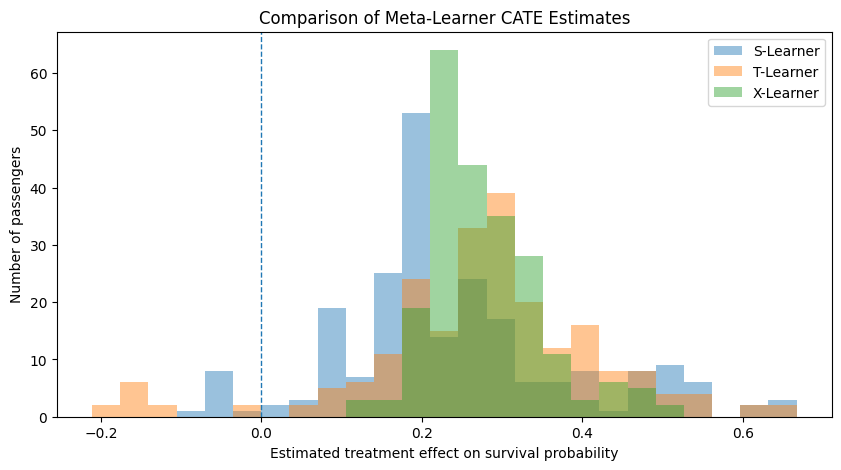

In [20]:
cate_comparison = pd.DataFrame({
    "S-Learner": cate_s,
    "T-Learner": cate_t,
    "X-Learner": cate_x
})

cate_comparison.plot(
    kind="hist",
    bins=25,
    alpha=0.45,
    figsize=(10, 5)
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Estimated treatment effect on survival probability")
plt.ylabel("Number of passengers")
plt.title("Comparison of Meta-Learner CATE Estimates")
plt.show()

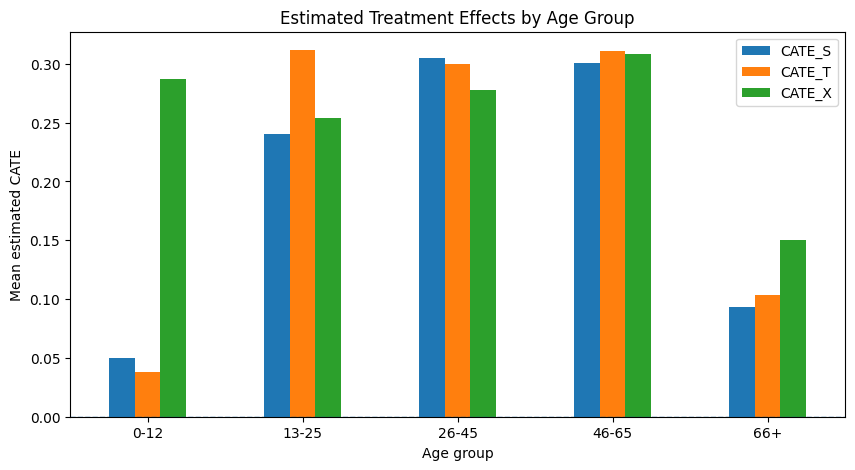

In [21]:
age_analysis = pd.DataFrame({
    "age": X_test["age"].to_numpy(),
    "CATE_S": cate_s,
    "CATE_T": cate_t,
    "CATE_X": cate_x
})

age_analysis = age_analysis.dropna(subset=["age"])

age_analysis["age_group"] = pd.cut(
    age_analysis["age"],
    bins=[0, 12, 25, 45, 65, 100],
    labels=["0-12", "13-25", "26-45", "46-65", "66+"]
)

age_summary = (
    age_analysis
    .groupby("age_group", observed=True)[["CATE_S", "CATE_T", "CATE_X"]]
    .mean()
)

age_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Age group")
plt.ylabel("Mean estimated CATE")
plt.title("Estimated Treatment Effects by Age Group")
plt.xticks(rotation=0)
plt.show()

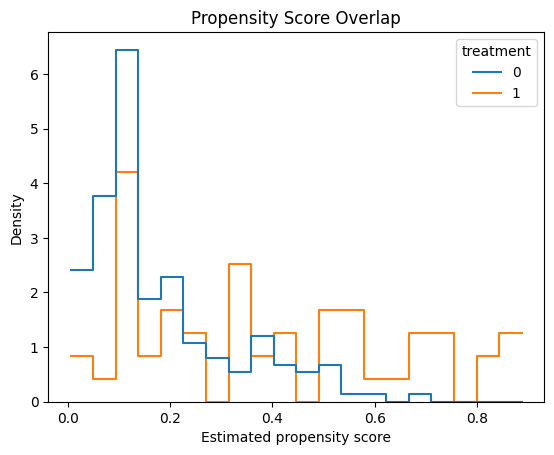

In [22]:
ps_df = pd.DataFrame({
    "propensity_score": e_test,
    "treatment": T_test.to_numpy()
})

sns.histplot(
    data=ps_df,
    x="propensity_score",
    hue="treatment",
    bins=20,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.xlabel("Estimated propensity score")
plt.title("Propensity Score Overlap")
plt.show()